# RQ4 CPU-Based Capacity Optimization and Overprovisioning Analysis

This notebook evaluates the CPU-based overprovisioning signal defined in RQ4: lifetime P95 CPU utilization below 40 percent. It also connects the result back to the workload archetypes generated in RQ3.

**Research question:** What percentage of Azure VMs show CPU-based overprovisioning signals, defined as lifetime P95 CPU utilization below 40 percent, and how does this proportion vary across empirically derived workload archetypes?

The notebook produces visible output at every step: data checks, VM-level metrics, threshold classification, overprovisioning percentage, archetype-level analysis, optional reproducibility classifier, charts, and saved artifacts.

## 1. Setup

The notebook uses the processed hourly dataset and, when available, the RQ3 cluster output. If the RQ3 output is not available, the notebook creates a lightweight fallback clustering based on VM-level features so RQ4 can still run end-to-end.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = "../data/processed/hourly_n2000.parquet"
RQ3_CLUSTER_PATH = "../data/reports/rq3_workload_clustering/rq3_vm_features_with_clusters.csv"
OUTPUT_DIR = "../data/reports/rq4_capacity_optimization"

if not os.path.exists(DATA_PATH):
    alt_path = "data/processed/hourly_n2000.parquet"
    if os.path.exists(alt_path):
        DATA_PATH = alt_path

if not os.path.exists(RQ3_CLUSTER_PATH):
    alt_cluster_path = "data/reports/rq3_workload_clustering/rq3_vm_features_with_clusters.csv"
    if os.path.exists(alt_cluster_path):
        RQ3_CLUSTER_PATH = alt_cluster_path

if not os.path.exists(OUTPUT_DIR):
    OUTPUT_DIR = "data/reports/rq4_capacity_optimization"

os.makedirs(OUTPUT_DIR, exist_ok=True)

CPU_MEAN = "avg_cpu_mean"
CPU_MAX = "avg_cpu_max"
CPU_MIN = "avg_cpu_min"
CPU_STD = "avg_cpu_std"
OVERPROVISIONED_P95_THRESHOLD = 40.0

print("DATA_PATH:", DATA_PATH)
print("RQ3_CLUSTER_PATH:", RQ3_CLUSTER_PATH if os.path.exists(RQ3_CLUSTER_PATH) else "Not found - fallback clustering will be used")
print("OUTPUT_DIR:", OUTPUT_DIR)
print("P95 CPU threshold:", OVERPROVISIONED_P95_THRESHOLD)

DATA_PATH: ../data/processed/hourly_n2000.parquet
RQ3_CLUSTER_PATH: data/reports/rq3_workload_clustering/rq3_vm_features_with_clusters.csv
OUTPUT_DIR: data/reports/rq4_capacity_optimization
P95 CPU threshold: 40.0


## 2. Load and Validate the Hourly Dataset

The RQ4 unit of analysis is the VM, but the source data is VM-hour. This step confirms the hourly data is complete and ready for VM-level aggregation.

In [2]:
def load_hourly_data(path=DATA_PATH):
    df = pd.read_parquet(path)
    df = df.sort_values(["vm_id", "hour_index"]).reset_index(drop=True)

    required_cols = [
        "vm_id", "hour_index", CPU_MEAN, CPU_MAX, CPU_MIN, CPU_STD,
        "hour_of_day", "day_index", "day_of_cycle"
    ]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    for col in [CPU_MEAN, CPU_MAX, CPU_MIN, CPU_STD]:
        df[col] = df[col].astype("float64")

    duplicate_count = df.duplicated(["vm_id", "hour_index"]).sum()
    if duplicate_count > 0:
        raise ValueError(f"Duplicate VM-hour rows found: {duplicate_count}")

    print("Shape:", df.shape)
    print("Unique VMs:", df["vm_id"].nunique())
    print("Unique hours:", df["hour_index"].nunique())
    display(df[["vm_id", "hour_index", CPU_MEAN, CPU_MAX, CPU_MIN, CPU_STD]].head())
    return df

hourly_df = load_hourly_data(DATA_PATH)

Shape: (1440000, 10)
Unique VMs: 2000
Unique hours: 720


,vm_id,hour_index,avg_cpu_mean,avg_cpu_max,avg_cpu_min,avg_cpu_std
0,0,0,1.467899,1.953717,1.281514,0.199937
1,0,1,1.555141,2.036626,1.382086,0.167614
2,0,2,1.683001,2.219195,1.511600,0.220013
3,0,3,1.752279,2.279033,1.615813,0.176076
4,0,4,1.926054,2.230747,1.774914,0.127170


## 3. Compute VM-Level Capacity Metrics

RQ4 uses the lifetime P95 of `avg_cpu_max` as the primary overprovisioning signal. This is intentionally conservative compared with average CPU because it considers peak hourly behavior across the 30-day trace.

In [3]:
def build_capacity_metrics(df):
    rows = []
    for vm_id, g in df.sort_values(["vm_id", "hour_index"]).groupby("vm_id"):
        mean_cpu = g[CPU_MEAN].to_numpy(dtype=float)
        max_cpu = g[CPU_MAX].to_numpy(dtype=float)
        std_cpu = g[CPU_STD].to_numpy(dtype=float)

        p95_max = float(np.percentile(max_cpu, 95))
        p95_mean = float(np.percentile(mean_cpu, 95))
        avg_cpu = float(np.mean(mean_cpu))
        median_cpu = float(np.median(mean_cpu))
        max_observed_cpu = float(np.max(max_cpu))
        std_mean_cpu = float(np.std(mean_cpu))
        q25, q75 = np.percentile(mean_cpu, [25, 75])

        rows.append({
            "vm_id": int(vm_id),
            "lifetime_mean_cpu": avg_cpu,
            "lifetime_median_cpu": median_cpu,
            "lifetime_p95_cpu_mean": p95_mean,
            "lifetime_p95_cpu_max": p95_max,
            "lifetime_max_cpu": max_observed_cpu,
            "std_mean_cpu": std_mean_cpu,
            "iqr_mean_cpu": float(q75 - q25),
            "mean_hourly_std": float(np.mean(std_cpu)),
            "burstiness_index": float((p95_mean - median_cpu) / (median_cpu + 1e-6)),
            "idle_fraction_lt_5": float(np.mean(mean_cpu < 5)),
            "low_fraction_lt_20": float(np.mean(mean_cpu < 20)),
            "high_fraction_gt_60": float(np.mean(mean_cpu > 60)),
            "complete_hours": int(len(g))
        })
    out = pd.DataFrame(rows)
    out["is_cpu_overprovisioned"] = (out["lifetime_p95_cpu_max"] < OVERPROVISIONED_P95_THRESHOLD).astype(int)
    out["p95_headroom_to_40"] = OVERPROVISIONED_P95_THRESHOLD - out["lifetime_p95_cpu_max"]
    out["p95_headroom_to_40"] = out["p95_headroom_to_40"].clip(lower=0)
    out["capacity_signal_strength"] = np.where(
        out["is_cpu_overprovisioned"] == 1,
        out["p95_headroom_to_40"] / OVERPROVISIONED_P95_THRESHOLD,
        0
    )
    return out

capacity_df = build_capacity_metrics(hourly_df)
print("Capacity metrics shape:", capacity_df.shape)
display(capacity_df.head())
display(capacity_df.describe().T.round(3))

Capacity metrics shape: (2000, 17)


,vm_id,lifetime_mean_cpu,lifetime_median_cpu,lifetime_p95_cpu_mean,lifetime_p95_cpu_max,lifetime_max_cpu,std_mean_cpu,iqr_mean_cpu,mean_hourly_std,burstiness_index,idle_fraction_lt_5,low_fraction_lt_20,high_fraction_gt_60,complete_hours,is_cpu_overprovisioned,p95_headroom_to_40,capacity_signal_strength
0,0,1.279185,0.949102,2.944079,3.421977,37.834385,0.928344,1.252089,0.156047,2.101960,0.998611,1.000000,0.0,720,1,36.578023,0.914451
1,1,4.758062,4.622718,5.482380,13.374448,74.709747,1.479756,0.484382,1.404490,0.185965,0.872222,0.998611,0.0,720,1,26.625552,0.665639
2,2,2.646828,2.231540,3.432912,7.234301,91.568214,2.087692,0.838043,0.599331,0.538360,0.975000,0.995833,0.0,720,1,32.765699,0.819142
3,3,0.417827,0.402262,0.543828,1.824460,5.041344,0.081167,0.070553,0.215191,0.351921,1.000000,1.000000,0.0,720,1,38.175540,0.954389
4,4,41.188540,41.084167,41.506249,41.896081,100.000000,0.888386,0.429658,0.687072,0.010274,0.000000,0.000000,0.0,720,0,0.000000,0.000000


,count,mean,std,min,25%,50%,75%,max
vm_id,2000.0,999.500,577.495,0.000,499.750,999.500,1499.250,1999.000
lifetime_mean_cpu,2000.0,6.734,10.916,0.003,1.805,3.923,6.903,98.751
lifetime_median_cpu,2000.0,6.270,11.170,0.003,1.607,3.495,6.320,98.962
lifetime_p95_cpu_mean,2000.0,10.257,15.635,0.004,2.507,5.084,9.401,99.382
lifetime_p95_cpu_max,2000.0,17.092,18.901,0.004,5.762,10.736,18.475,100.000
lifetime_max_cpu,2000.0,59.454,32.458,0.005,29.051,63.016,92.482,100.000
std_mean_cpu,2000.0,2.564,4.014,0.000,0.392,1.171,3.015,36.020
iqr_mean_cpu,2000.0,1.992,5.450,0.000,0.181,0.435,1.236,79.634
mean_hourly_std,2000.0,1.279,1.743,0.000,0.403,0.855,1.316,19.553
burstiness_index,2000.0,1.510,10.897,0.001,0.163,0.283,0.711,441.340


## 4. Overall CPU-Based Overprovisioning Result

This is the primary RQ4 result: the percentage of VMs with lifetime P95 CPU max below 40 percent.

,total_vms,overprovisioned_vm_count,overprovisioned_vm_percent,threshold_p95_cpu_max,mean_capacity_signal_strength,median_p95_cpu_max
0,2000,1759,87.95,40.0,0.634,10.736


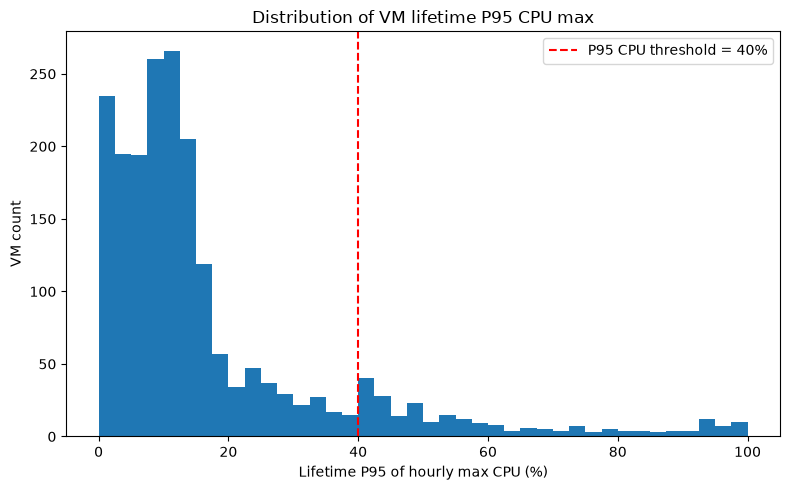

In [4]:
total_vms = len(capacity_df)
overprov_count = int(capacity_df["is_cpu_overprovisioned"].sum())
overprov_pct = overprov_count / total_vms * 100

summary_df = pd.DataFrame([{
    "total_vms": total_vms,
    "overprovisioned_vm_count": overprov_count,
    "overprovisioned_vm_percent": overprov_pct,
    "threshold_p95_cpu_max": OVERPROVISIONED_P95_THRESHOLD,
    "mean_capacity_signal_strength": capacity_df["capacity_signal_strength"].mean(),
    "median_p95_cpu_max": capacity_df["lifetime_p95_cpu_max"].median()
}])

display(summary_df.round(3))

plt.figure(figsize=(8, 5))
plt.hist(capacity_df["lifetime_p95_cpu_max"], bins=40)
plt.axvline(OVERPROVISIONED_P95_THRESHOLD, color="red", linestyle="--", label="P95 CPU threshold = 40%")
plt.xlabel("Lifetime P95 of hourly max CPU (%)")
plt.ylabel("VM count")
plt.title("Distribution of VM lifetime P95 CPU max")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Attach RQ3 Workload Archetypes

RQ4 asks how the overprovisioning proportion varies across empirically derived workload archetypes. If the RQ3 cluster file exists, it is used directly. Otherwise, this notebook generates a fallback K-Means clustering so the analysis can still run.

In [5]:
def attach_or_create_archetypes(capacity_df):
    if os.path.exists(RQ3_CLUSTER_PATH):
        rq3 = pd.read_csv(RQ3_CLUSTER_PATH)
        keep_cols = [c for c in ["vm_id", "cluster", "archetype"] if c in rq3.columns]
        merged = capacity_df.merge(rq3[keep_cols], on="vm_id", how="left")
        if "archetype" not in merged.columns or merged["archetype"].isna().all():
            merged["archetype"] = "Cluster " + merged["cluster"].astype(str)
        print("Attached RQ3 archetypes from:", RQ3_CLUSTER_PATH)
        return merged

    fallback = capacity_df.copy()
    feature_cols = [
        "lifetime_mean_cpu", "lifetime_median_cpu", "lifetime_p95_cpu_mean",
        "lifetime_p95_cpu_max", "std_mean_cpu", "iqr_mean_cpu", "burstiness_index",
        "idle_fraction_lt_5", "low_fraction_lt_20", "high_fraction_gt_60"
    ]
    X = fallback[feature_cols].replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True)).fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    km = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=30)
    fallback["cluster"] = km.fit_predict(X_scaled)

    cluster_profile = fallback.groupby("cluster")[[
        "lifetime_mean_cpu", "lifetime_p95_cpu_max", "std_mean_cpu", "burstiness_index",
        "idle_fraction_lt_5", "high_fraction_gt_60"
    ]].mean()

    names = {}
    for cluster_id, row in cluster_profile.iterrows():
        if row["idle_fraction_lt_5"] >= 0.70 and row["lifetime_mean_cpu"] < 10:
            name = "Idle / very low utilization"
        elif row["high_fraction_gt_60"] >= 0.20 or row["lifetime_p95_cpu_max"] >= 60:
            name = "High utilization"
        elif row["burstiness_index"] >= cluster_profile["burstiness_index"].quantile(0.75) or row["std_mean_cpu"] >= cluster_profile["std_mean_cpu"].quantile(0.75):
            name = "Bursty / variable"
        else:
            name = "Steady moderate"
        names[cluster_id] = name
    fallback["archetype"] = fallback["cluster"].map(names)
    print("RQ3 archetype file not found. Created fallback archetypes inside RQ4 notebook.")
    return fallback

capacity_with_archetypes = attach_or_create_archetypes(capacity_df)
display(capacity_with_archetypes.head())
print("Archetype counts:")
display(capacity_with_archetypes["archetype"].value_counts().to_frame("vm_count"))

Attached RQ3 archetypes from: data/reports/rq3_workload_clustering/rq3_vm_features_with_clusters.csv


,vm_id,lifetime_mean_cpu,lifetime_median_cpu,lifetime_p95_cpu_mean,lifetime_p95_cpu_max,lifetime_max_cpu,std_mean_cpu,iqr_mean_cpu,mean_hourly_std,burstiness_index,idle_fraction_lt_5,low_fraction_lt_20,high_fraction_gt_60,complete_hours,is_cpu_overprovisioned,p95_headroom_to_40,capacity_signal_strength,cluster,archetype
0,0,1.279185,0.949102,2.944079,3.421977,37.834385,0.928344,1.252089,0.156047,2.101960,0.998611,1.000000,0.0,720,1,36.578023,0.914451,0,Idle / very low utilization
1,1,4.758062,4.622718,5.482380,13.374448,74.709747,1.479756,0.484382,1.404490,0.185965,0.872222,0.998611,0.0,720,1,26.625552,0.665639,0,Idle / very low utilization
2,2,2.646828,2.231540,3.432912,7.234301,91.568214,2.087692,0.838043,0.599331,0.538360,0.975000,0.995833,0.0,720,1,32.765699,0.819142,1,Steady moderate
3,3,0.417827,0.402262,0.543828,1.824460,5.041344,0.081167,0.070553,0.215191,0.351921,1.000000,1.000000,0.0,720,1,38.175540,0.954389,0,Idle / very low utilization
4,4,41.188540,41.084167,41.506249,41.896081,100.000000,0.888386,0.429658,0.687072,0.010274,0.000000,0.000000,0.0,720,0,0.000000,0.000000,3,Bursty / variable


Archetype counts:


,vm_count
archetype,
Idle / very low utilization,1134
Steady moderate,558
Bursty / variable,249
High utilization,59


## 6. Overprovisioning by Workload Archetype

This section directly answers the second part of RQ4 by comparing the CPU-based overprovisioning rate across workload archetypes.

,archetype,vm_count,overprovisioned_vm_count,mean_p95_cpu_max,median_p95_cpu_max,mean_cpu,mean_capacity_signal_strength,overprovisioned_vm_percent
2,Idle / very low utilization,1134,1117,9.040,8.185,3.341,0.775,98.501
3,Steady moderate,558,527,15.451,13.182,4.421,0.637,94.444
0,Bursty / variable,249,115,41.793,40.927,16.782,0.132,46.185
1,High utilization,59,0,83.128,86.320,51.416,0.000,0.000


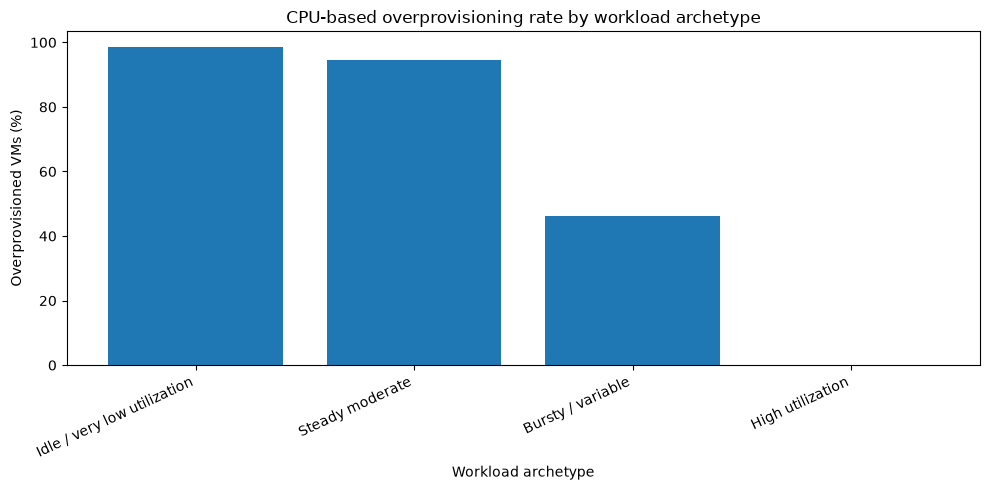

In [6]:
archetype_summary = capacity_with_archetypes.groupby("archetype").agg(
    vm_count=("vm_id", "count"),
    overprovisioned_vm_count=("is_cpu_overprovisioned", "sum"),
    mean_p95_cpu_max=("lifetime_p95_cpu_max", "mean"),
    median_p95_cpu_max=("lifetime_p95_cpu_max", "median"),
    mean_cpu=("lifetime_mean_cpu", "mean"),
    mean_capacity_signal_strength=("capacity_signal_strength", "mean")
).reset_index()

archetype_summary["overprovisioned_vm_percent"] = (
    archetype_summary["overprovisioned_vm_count"] / archetype_summary["vm_count"] * 100
)
archetype_summary = archetype_summary.sort_values("overprovisioned_vm_percent", ascending=False)

display(archetype_summary.round(3))

plt.figure(figsize=(10, 5))
plt.bar(archetype_summary["archetype"], archetype_summary["overprovisioned_vm_percent"])
plt.ylabel("Overprovisioned VMs (%)")
plt.xlabel("Workload archetype")
plt.title("CPU-based overprovisioning rate by workload archetype")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 7. Capacity Opportunity Signal

Because the dataset contains CPU only and no VM size, memory, network, storage, licensing, or price metadata, this notebook does not claim implementation-ready resizing savings. Instead, it reports a CPU-based opportunity signal.

The `capacity_signal_strength` value expresses how far each overprovisioned VM's P95 CPU max is below the 40 percent threshold. It is a screening indicator, not a confirmed savings estimate.

,capacity_signal_band,vm_count,mean_p95_cpu_max,overprovisioned_vm_count
0,No signal,241,60.207,0
1,Weak,81,34.456,81
2,Moderate,147,24.681,147
3,Strong,648,13.467,648
4,Very strong,883,5.128,883


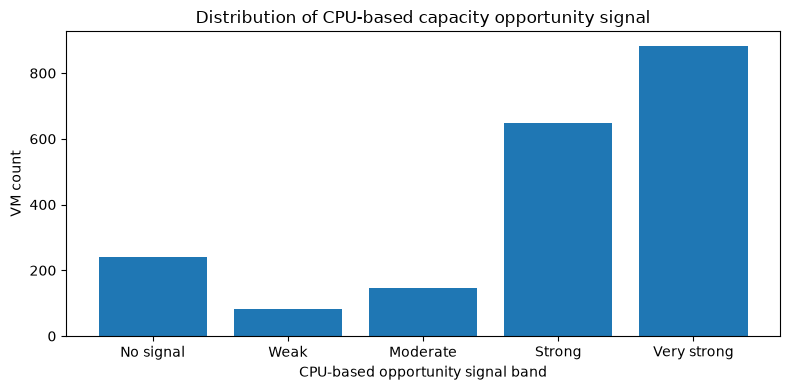

In [7]:
opportunity_bins = pd.cut(
    capacity_with_archetypes["capacity_signal_strength"],
    bins=[-0.001, 0, 0.25, 0.50, 0.75, 1.00],
    labels=["No signal", "Weak", "Moderate", "Strong", "Very strong"]
)
capacity_with_archetypes["capacity_signal_band"] = opportunity_bins

signal_summary = capacity_with_archetypes.groupby("capacity_signal_band", observed=False).agg(
    vm_count=("vm_id", "count"),
    mean_p95_cpu_max=("lifetime_p95_cpu_max", "mean"),
    overprovisioned_vm_count=("is_cpu_overprovisioned", "sum")
).reset_index()

display(signal_summary.round(3))

plt.figure(figsize=(8, 4))
plt.bar(signal_summary["capacity_signal_band"].astype(str), signal_summary["vm_count"])
plt.xlabel("CPU-based opportunity signal band")
plt.ylabel("VM count")
plt.title("Distribution of CPU-based capacity opportunity signal")
plt.tight_layout()
plt.show()

## 8. Optional Rule-Reproduction Classifier

RQ4 is primarily a rule-based CPU screen, but a simple classifier is included to test whether VM-level behavioral features can reproduce the P95-based classification. This is not a replacement for the rule; it is a validation check on whether the overprovisioning signal is learnable from related VM-level features.

In [8]:
classifier_features = [
    "lifetime_mean_cpu", "lifetime_median_cpu", "lifetime_p95_cpu_mean",
    "lifetime_max_cpu", "std_mean_cpu", "iqr_mean_cpu", "mean_hourly_std",
    "burstiness_index", "idle_fraction_lt_5", "low_fraction_lt_20", "high_fraction_gt_60"
]

clf_df = capacity_with_archetypes[classifier_features + ["is_cpu_overprovisioned"]].replace([np.inf, -np.inf], np.nan)
clf_df[classifier_features] = clf_df[classifier_features].fillna(clf_df[classifier_features].median(numeric_only=True)).fillna(0)

X = clf_df[classifier_features]
y = clf_df["is_cpu_overprovisioned"].astype(int)

if y.nunique() < 2:
    print("Classifier skipped because only one class is present in the target.")
    classifier_results_df = pd.DataFrame()
else:
    stratify_arg = y if y.value_counts().min() >= 2 else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=stratify_arg
    )
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        random_state=RANDOM_STATE,
        class_weight="balanced_subsample",
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    classifier_results_df = pd.DataFrame([{
        "model": "RandomForest rule-reproduction check",
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "test_rows": len(y_test)
    }])
    print("Confusion matrix:")
    display(pd.DataFrame(confusion_matrix(y_test, pred, labels=[0, 1]), index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"]))
    print("Classification report:")
    print(classification_report(y_test, pred, zero_division=0))
    display(classifier_results_df.round(3))

    importance_df = pd.DataFrame({
        "feature": classifier_features,
        "importance": rf.feature_importances_
    }).sort_values("importance", ascending=False)
    display(importance_df.round(4))

Confusion matrix:


,Pred 0,Pred 1
Actual 0,57,3
Actual 1,17,423


Classification report:
              precision    recall  f1-score   support

           0       0.77      0.95      0.85        60
           1       0.99      0.96      0.98       440

    accuracy                           0.96       500
   macro avg       0.88      0.96      0.91       500
weighted avg       0.97      0.96      0.96       500



,model,precision,recall,f1,test_rows
0,RandomForest rule-reproduction check,0.993,0.961,0.977,500


,feature,importance
6,mean_hourly_std,0.2406
2,lifetime_p95_cpu_mean,0.2334
9,low_fraction_lt_20,0.1869
4,std_mean_cpu,0.0923
0,lifetime_mean_cpu,0.0690
8,idle_fraction_lt_5,0.0610
3,lifetime_max_cpu,0.0404
5,iqr_mean_cpu,0.0266
1,lifetime_median_cpu,0.0229
7,burstiness_index,0.0201


## 9. Sensitivity Analysis Around the P95 Threshold

The primary threshold is 40 percent. This section reports how the result changes under nearby thresholds. This is useful for explaining robustness without changing the main RQ4 definition.

,p95_cpu_threshold,vm_count_below_threshold,vm_percent_below_threshold
0,20,1531,76.55
1,30,1678,83.90
2,40,1759,87.95
3,50,1864,93.20
4,60,1910,95.50


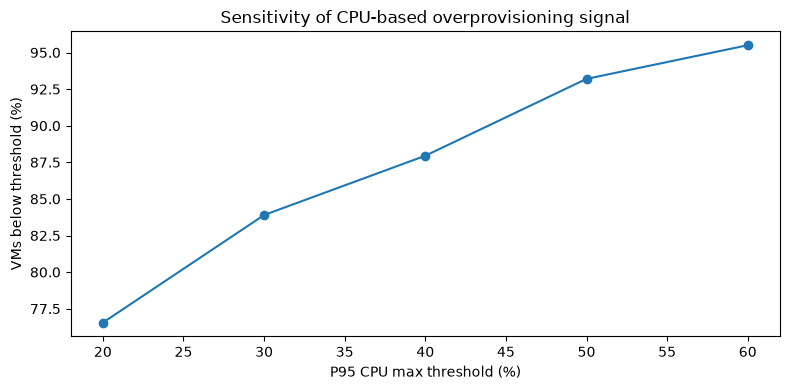

In [9]:
sensitivity_rows = []
for threshold in [20, 30, 40, 50, 60]:
    count = int((capacity_with_archetypes["lifetime_p95_cpu_max"] < threshold).sum())
    pct = count / len(capacity_with_archetypes) * 100
    sensitivity_rows.append({
        "p95_cpu_threshold": threshold,
        "vm_count_below_threshold": count,
        "vm_percent_below_threshold": pct
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
display(sensitivity_df.round(3))

plt.figure(figsize=(8, 4))
plt.plot(sensitivity_df["p95_cpu_threshold"], sensitivity_df["vm_percent_below_threshold"], marker="o")
plt.xlabel("P95 CPU max threshold (%)")
plt.ylabel("VMs below threshold (%)")
plt.title("Sensitivity of CPU-based overprovisioning signal")
plt.tight_layout()
plt.show()

## 10. Save RQ4 Outputs

The saved outputs support the final RQ4 result tables, figures, and interpretation.

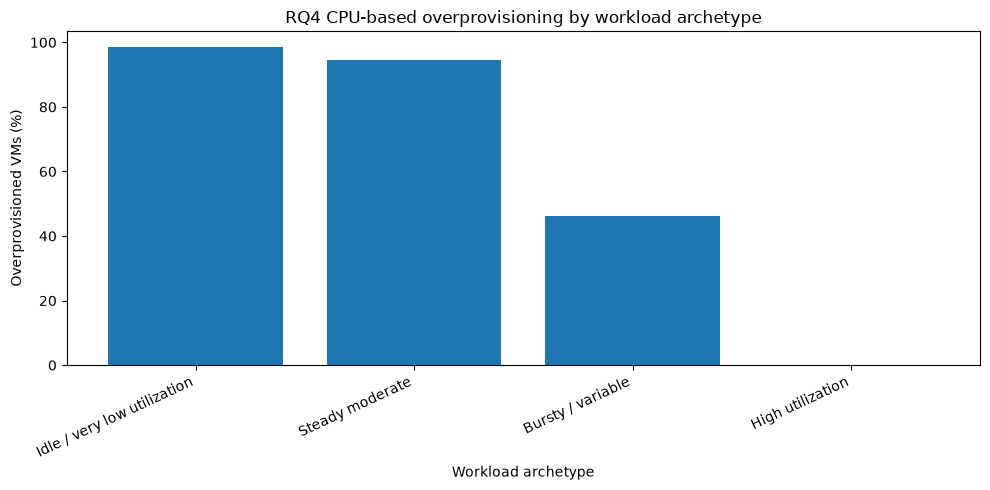

Saved RQ4 outputs to: data/reports/rq4_capacity_optimization
Overall overprovisioned percentage: 87.95
Archetype plot: data/reports/rq4_capacity_optimization\rq4_overprovisioning_by_archetype.png


In [10]:
capacity_with_archetypes.to_csv(os.path.join(OUTPUT_DIR, "rq4_vm_capacity_signals.csv"), index=False)
summary_df.to_csv(os.path.join(OUTPUT_DIR, "rq4_overall_summary.csv"), index=False)
archetype_summary.to_csv(os.path.join(OUTPUT_DIR, "rq4_archetype_summary.csv"), index=False)
signal_summary.to_csv(os.path.join(OUTPUT_DIR, "rq4_capacity_signal_bands.csv"), index=False)
sensitivity_df.to_csv(os.path.join(OUTPUT_DIR, "rq4_threshold_sensitivity.csv"), index=False)
if 'classifier_results_df' in globals() and len(classifier_results_df):
    classifier_results_df.to_csv(os.path.join(OUTPUT_DIR, "rq4_rule_reproduction_classifier.csv"), index=False)

plt.figure(figsize=(10, 5))
plt.bar(archetype_summary["archetype"], archetype_summary["overprovisioned_vm_percent"])
plt.ylabel("Overprovisioned VMs (%)")
plt.xlabel("Workload archetype")
plt.title("RQ4 CPU-based overprovisioning by workload archetype")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
archetype_plot_path = os.path.join(OUTPUT_DIR, "rq4_overprovisioning_by_archetype.png")
plt.savefig(archetype_plot_path, dpi=150)
plt.show()

print("Saved RQ4 outputs to:", OUTPUT_DIR)
print("Overall overprovisioned percentage:", round(overprov_pct, 3))
print("Archetype plot:", archetype_plot_path)

## 11. Report-Ready Interpretation Template

Use the generated values from the output tables to complete the final RQ4 write-up.

> RQ4 classified VMs as CPU-based overprovisioning candidates when lifetime P95 of hourly max CPU was below 40 percent. Using this criterion, [count] of [total] VMs, or [percent] percent, showed CPU-based overprovisioning signals. The rate varied across workload archetypes, with the highest rate observed in [archetype] and the lowest rate observed in [archetype]. Because the dataset contains CPU utilization only, these findings should be interpreted as capacity optimization screening signals rather than implementation-ready resizing recommendations. Memory, network, storage, licensing, and application constraints must be reviewed before production action.